# **K-means Clustering**

### Objectives
* Use scikit-learn k-means clustering to cluster data
* Apply k-means clustering on a real world data for Customer Segmentation

### Introduction
**K-means** is vastly used for clustering in many data science applications. It is especially useful if you need to quickly discober insights from **unlabeled data**.

Real-world applications of k-means include:
* Customer segmentation
* Understanding what website visitors are trying to accompllish
* Pattern recognition
* Feature engineering
* Data compression

---

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


import warnings
warnings.filterwarnings('ignore')

---

## K-Means on a Synthetic Dataset

In [2]:
np.random.seed(0)

Next, we will be making random clusters of points by using the `make_blobs` class. the `make_blobs` class can take in many inputs, but we will be using these specific ones.

In [3]:
from sklearn.datasets import make_blobs


X, y = make_blobs(n_samples=5000, centers=[[4,4], [-2,-1], [2,-3], [1,1]], cluster_std=0.9)

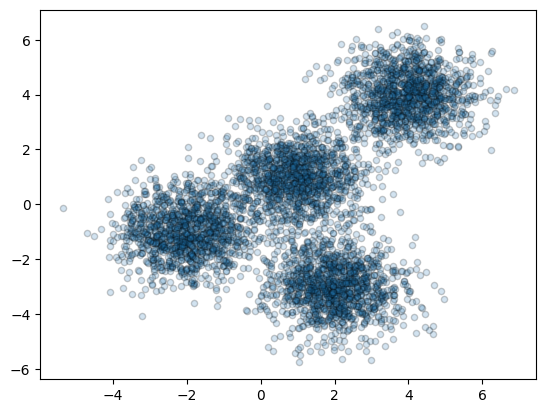

In [5]:
plt.scatter(X[:,0], X[:,1], marker='.', alpha=0.2, ec='k', s=80)
plt.show()

### Setting up K-means

The KMeans class has many parameters that can be used, but we will be using these three:

- `init`: Initialization method of the centroids.
  - Value will be: `k-means++` 
  - `k-means++`: Selects initial cluster centres for k-means clustering in a smart way to speed up convergence.
- `n_clusters`: The number of clusters to form as well as the number of centroids to generate. 
  -  Value will be: 4 (since we have 4 centres) 
- `n_init`: Number of times the k-means algorithm will be run with different centroid seeds. The final results will be the best output of n_init consecutive runs in terms of inertia. 
   - Value will be: 12  


Initialize `KMeans` with these parameters, where the output variable is called `k_means`.


In [6]:
from sklearn.cluster import KMeans

k_means = KMeans(init="k-means++", n_clusters=4, n_init=12)
k_means.fit(X)

KMeans(n_clusters=4, n_init=12)

Now let's get the label for each point in the model using the `.labels_` attribute and save them as `k_means_labels`

In [7]:
k_means_labels = k_means.labels_
k_means_labels

array([0, 3, 3, ..., 1, 0, 0], dtype=int32)

We will also get the coordinates of the cluster centers using `k_means.cluster_centers_` and save it as `k_means_cluster_centers`.

In [8]:
k_means_cluster_centers = k_means.cluster_centers_
k_means_cluster_centers

array([[-2.03743147, -0.99782524],
       [ 3.97334234,  3.98758687],
       [ 0.96900523,  0.98370298],
       [ 1.99741008, -3.01666822]])

#### Creating the Visual Plot

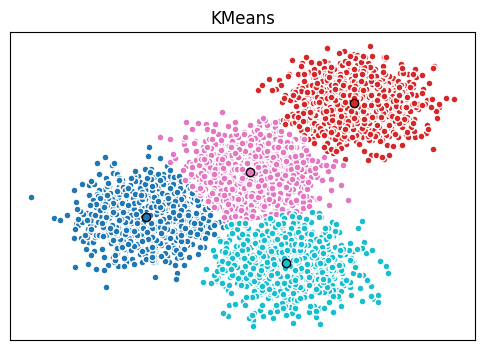

In [9]:
# Initialize the plot with the specified dimensions.
fig = plt.figure(figsize=(6,4))

# Colors uses a color map, which will produce an array of colors based on
# the number of labels there are. We use set(k_means_labels) to get the unique labels
colors = plt.cm.tab10(np.linspace(0, 1, len(set(k_means_labels))))


# Create a plot
ax = fig.add_subplot(1, 1, 1)

# For loop that plots the data points and centroids
# k will range from 0-1, which will match the possible clusters that each data point is in
for k, col in zip(range(len([[4, 4], [-2, 1], [2, -3], [1,1]])), colors):

    # Create a list of all data points, where the data points that are
    # in the cluster (ex. cluster 0) are labeled as true, else they are labeled as false
    my_members = ((k_means_labels == k))

    # Define the centroid, or cluster center
    cluster_center = k_means_cluster_centers[k]

    # Plots the datapoints with color col
    ax.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.', ms=10)

    # Plots the centroids with specified color, but with a darker outline
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col, markeredgecolor='k', markersize=6)

# Title of the plot
ax.set_title('KMeans')

# Remove x-axis ticks
ax.set_xticks(())

# Remove y-axis ticks
ax.set_yticks(())

# Show the plot
plt.show()

---

#### Experiment

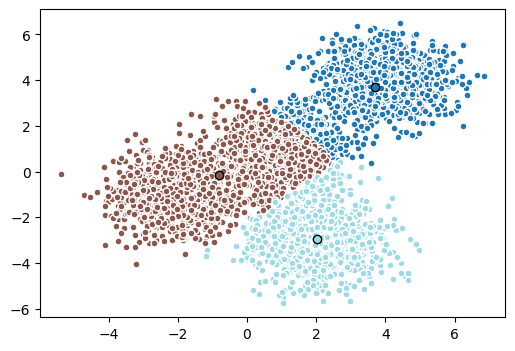

In [28]:
# Try with n_cluster = 3
k_means3 = KMeans(n_clusters=3, init='k-means++', n_init=12)
k_means3.fit(X)

plt.figure(figsize=(6,4))
colors = plt.cm.tab20(np.linspace(0, 1, len(set(k_means3.labels_))))
for k, col in zip(range(len(k_means3.cluster_centers_)),colors):
    my_members = ((k_means3.labels_ == k))
    cluster_center = k_means3.cluster_centers_[k]
    plt.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.', ms=10)
    plt.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col, markeredgecolor='k', markersize=6)
plt.show()

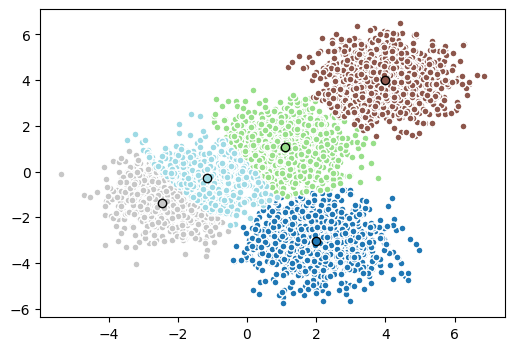

In [39]:
# Try with n_cluster = 3
k_means3 = KMeans(n_clusters=5, init='k-means++', n_init=12)
k_means3.fit(X)

plt.figure(figsize=(6,4))
colors = plt.cm.tab20(np.linspace(0, 1, len(set(k_means3.labels_))))
for k, col in zip(range(len(k_means3.cluster_centers_)),colors):
    my_members = ((k_means3.labels_ == k))
    cluster_center = k_means3.cluster_centers_[k]
    plt.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.', ms=10)
    plt.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col, markeredgecolor='k', markersize=6)
plt.show()

For k=3, the value of within-cluster sum of squares will be higher than that for k=4, since the points from different natural clusters are being grouped together, leading to underfitting of the k-means model. For k=5, the value of will be lesser than that for k=4, since the points are distributed into more clusters than needed, leading to over-fitting of the k-means model.

---

## **Customer Segmentation with k-means**

We have a customer dataset, and we'll apply customer segmentation to this historical data. Customer segmentation is the practice of partitioning a customer base into groups of individuals that have similar characteristics. It is a significant strategy as a business can target these specific groups of customers and effectively allocate marketing resources. For example, one group might contain customers who are high-profit and low-risk, or more likely to purchase products, or subscribe to a service. A business task is to retain those customers.

In [40]:
# Load the data
path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%204/data/Cust_Segmentation.csv"
raw = pd.read_csv(path)
raw.head()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9
3,4,29,2,4,19,0.681,0.516,0.0,NBA009,6.3
4,5,47,1,31,253,9.308,8.908,0.0,NBA008,7.2


#### Pre-processing
As we can see, `Address` in this dataset is a categorical variable. The k-means algorithm doesn't work directlly with categorical variables because the *Euclidean* distance function isn't meaningful for them. We could one-hot encode the categorical feature.

In [41]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer Id      850 non-null    int64  
 1   Age              850 non-null    int64  
 2   Edu              850 non-null    int64  
 3   Years Employed   850 non-null    int64  
 4   Income           850 non-null    int64  
 5   Card Debt        850 non-null    float64
 6   Other Debt       850 non-null    float64
 7   Defaulted        700 non-null    float64
 8   Address          850 non-null    object 
 9   DebtIncomeRatio  850 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 66.5+ KB


In [61]:
# Drop identifier columns such as 'Customer Id', 'Address' 
data = raw.dropna().drop(columns=['Customer Id', 'Address'])

data.shape

(700, 8)

After dropping NaNs and identifier columns like `Customer Id`, `address`, now we have 700 rows and 8 columns.

#### Normalizing over the standard deviation
Now let's normalize the dataset. But why do we need normalization in the first place? Normalization is a statistical method that helps mathematical-based algorithms to interpret features with different magnitudes and distributions equally, transforming the features so they have zero mean and standard deviation of one. We use `StandardScaler()` to normalize, or standardize our dataset.

In [62]:
from sklearn.preprocessing import StandardScaler

X = data.values
X = StandardScaler().fit_transform(X)

In [77]:
X.mean()

2.854859206178974e-18

In [78]:
np.std(X)

1.0

---

### Modeling

In [64]:
from sklearn.cluster import KMeans

nclusters = 3
k_means = KMeans(n_clusters=nclusters, init='k-means++', n_init=12)
k_means.fit(X)
labels = k_means.labels_

#### Insights

We assign the k-means cluster labels to each row in the dataframe

In [69]:
data['clus_km'] = labels

We can easily check the centroid values by averaging the features in each cluster. These values indicate the central point of the cluster from the vantage point of the field in question.

In [70]:
data.groupby('clus_km').mean()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
clus_km,,,,,,,,
0,43.112000,1.960000,16.904000,96.056000,4.172896,7.811616,0.208000,14.398400
1,33.727053,1.601449,7.644928,36.246377,0.788126,1.748710,0.000000,7.581884
2,31.366460,1.850932,3.689441,30.484472,1.488199,2.734901,0.975155,13.936025


Now, let's look at the distribution of customers based on their education, age and income. We can choose to visualize this as a 2D scatter plot with `Age` on the x-axis, `Income` on the y-axis and the marker size representing education. The scatter points will be assigned different colors based on different class labels.

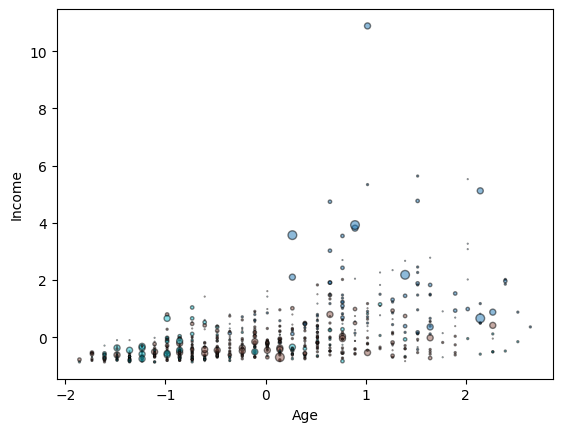

In [73]:
area = np.pi * (X[:, 1])**2
plt.scatter(X[:, 0], X[:, 3], s=area, c=labels.astype(float),
            cmap='tab10', ec='k', alpha=0.5)
plt.xlabel("Age")
plt.ylabel("Income")
plt.show()

We can also see this distribution in 3 dimensions for better understanding. Here, the `education` parameter will represent the third axis instead of the marker size.

In [74]:
# Create interactive 3D scatter plot
fig = px.scatter_3d(X, x=1, y=0, z=3, opacity=0.7, color=labels.astype(float))

fig.update_traces(marker=dict(size=5, line=dict(width=.25)), showlegend=False)
fig.update_layout(coloraxis_showscale=False, width=1000, height=800, scene=dict(
    xaxis = dict(title='Education'),
    yaxis = dict(title='Age'),
    zaxis = dict(title='Income')
))

fig.show()

k-means will partition your customers into mutually exclusice groups, for example, into 3 clusters. The customers in each cluster are similar to each other demographically.

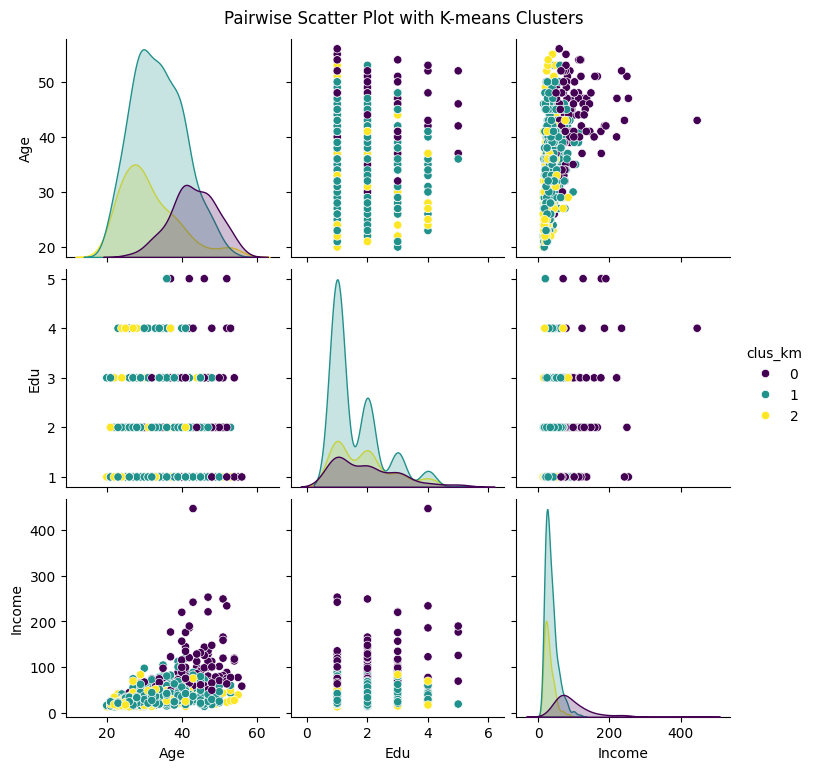

In [75]:
cust_df_sub = data[['Age', 'Edu', 'Income', 'clus_km']].copy()
sns.pairplot(cust_df_sub, hue='clus_km', palette='viridis', diag_kind='kde')
plt.suptitle("Pairwise Scatter Plot with K-means Clusters", y=1.02)
plt.show()

The 3 clusters can be:
* Late career, Affulent, and Educated
* Mid Career, and Middle Income
* Early Career, and Low Income